# Tokam2D Active Testing Notebook

This notebook helps you actively test your approach using the existing codebase. It focuses on:

- Inspecting the dataset and labels
- Training a model via solution/submission.py
- Sanity-checking predictions locally
- Generating XML outputs via the ingestion flow

**Note:** You do not have access to test annotations. Local checks are only for sanity; final evaluation happens on the website.

In [1]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / 'ingestion_program').exists() and (parent / 'solution').exists():
            return parent
    raise RuntimeError('Repo root not found')

repo_root = find_repo_root(Path.cwd())
repo_root

PosixPath('/home/tppn/Documents/Code/codalab_tokam2d')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(repo_root / 'ingestion_program'))
sys.path.append(str(repo_root / 'solution'))

from tokam2d_utils import TokamDataset

In [3]:
train_dir = repo_root / 'dev_phase' / 'input_data' / 'train'
train_dataset = TokamDataset(train_dir, include_unlabeled=False)
print('Train frames:', len(train_dataset))
print('Example frame indices:', train_dataset.idx_to_frame[:5])

Found annotations for 30 frames in 2 files.
Loaded 30 frames.
Train frames: 30
Example frame indices: ['blob_i-50', 'blob_i-100', 'blob_i-150', 'blob_i-200', 'blob_i-250']


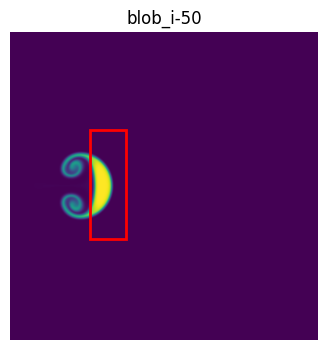

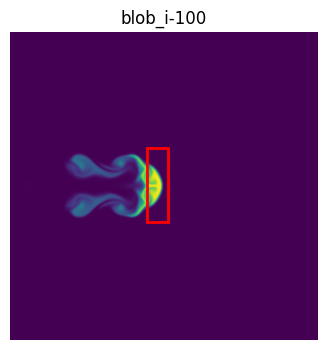

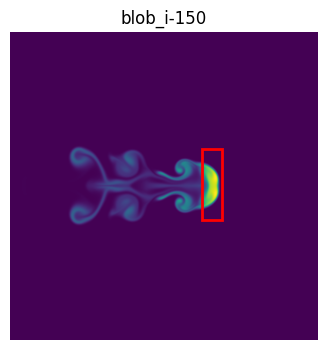

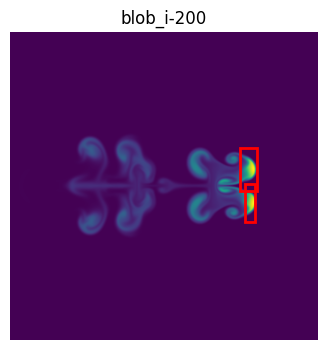

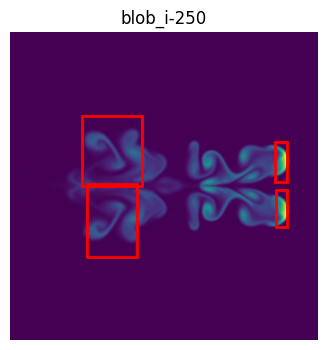

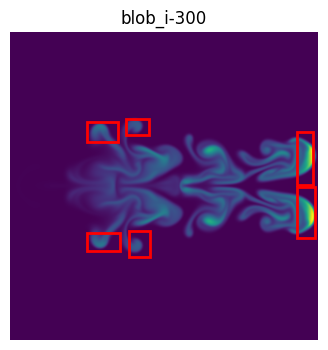

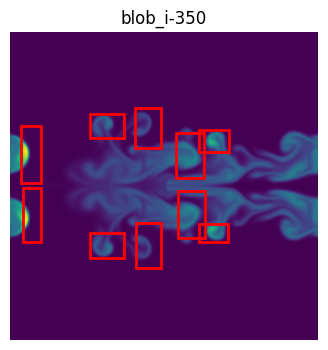

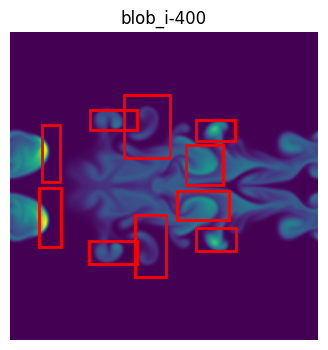

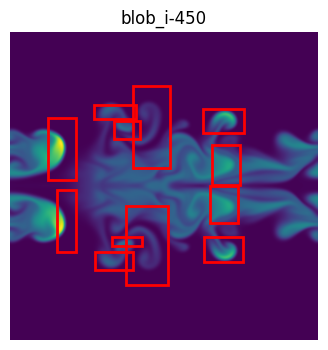

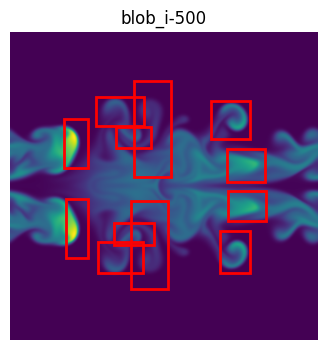

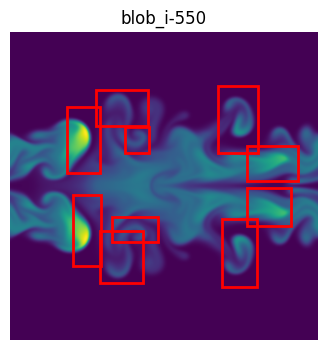

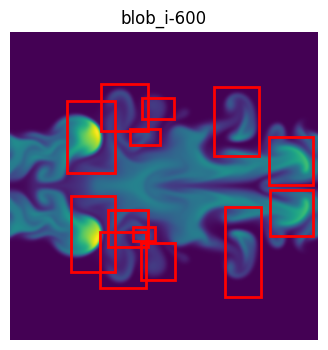

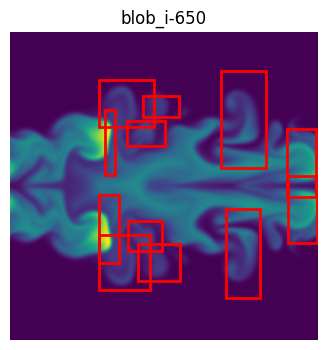

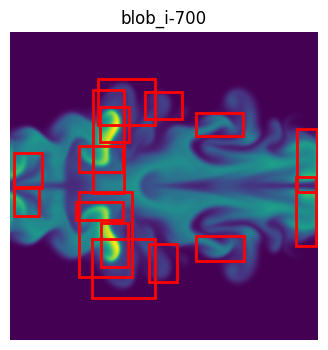

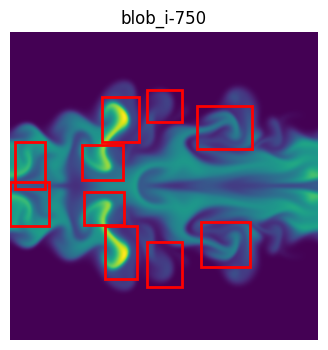

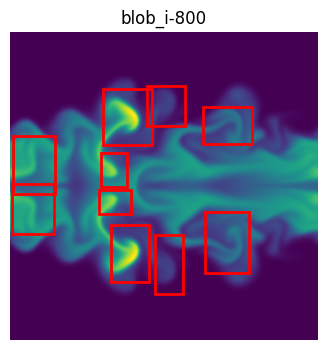

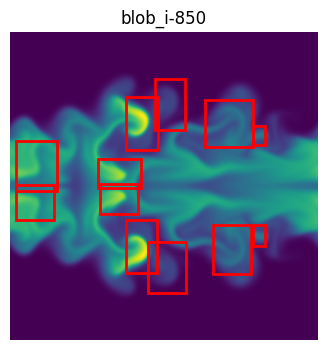

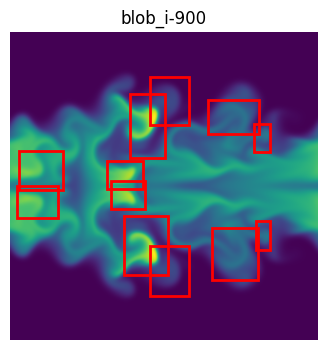

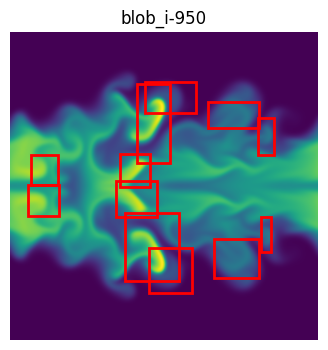

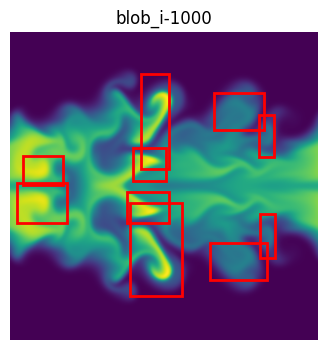

In [4]:
def show_frame_with_boxes(image, boxes=None, title=None):
    img = image.squeeze().numpy()
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="viridis")
    if boxes is not None:
        for (x1, y1, x2, y2) in boxes:
            plt.gca().add_patch(
                plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              fill=False, edgecolor="red", linewidth=2)
            )
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

# Visualize a few samples with ground-truth boxes
for i in range(20):
    image, target = train_dataset[i]
    boxes = target["boxes"]
    if boxes is not None:
        boxes = boxes.numpy()
    show_frame_with_boxes(image, boxes, title=target["frame_index"])

In [5]:
from torch.utils.data import DataLoader, Subset
from ingestion_program.ingestion import collate_fn
from discopat.metrics import compute_iomean

# Small train/val split for a quick proxy check (not official)
rng = np.random.default_rng(0)
indices = np.arange(len(train_dataset))
rng.shuffle(indices)
split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]
val_subset = Subset(train_dataset, val_idx[:20])  # keep it light
val_loader = DataLoader(val_subset, batch_size=2, collate_fn=collate_fn)

def build_targets_from_batch(targets):
    out = {}
    for t in targets:
        frame = t["frame_index"]
        boxes = t["boxes"]
        if boxes is None:
            boxes = []
        else:
            boxes = boxes.tolist()
        out[frame] = {"boxes": boxes}
    return out

def build_predictions_from_outputs(outputs, targets):
    out = {}
    for y_pred, t in zip(outputs, targets):
        frame = t["frame_index"]
        out[frame] = {
            "boxes": y_pred["boxes"].detach().cpu().tolist(),
            "scores": y_pred["scores"].detach().cpu().tolist(),
        }
    return out

def match_gts_and_preds(groundtruths, predictions, scores, threshold):
    if len(predictions) == 0:
        return len(groundtruths), np.empty((0, 2))
    predictions = np.array(predictions)
    scores = np.array(scores)
    order = np.argsort(-scores)
    predictions = predictions[order]
    scores = scores[order]

    gt_matched = np.zeros(len(groundtruths), dtype=bool)
    tps = np.zeros(len(predictions))

    for i, pred in enumerate(predictions):
        loc_scores = [compute_iomean(pred, gt) for gt in groundtruths]
        best_gt = int(np.argmax(loc_scores))
        best_loc = loc_scores[best_gt]
        if best_loc >= threshold and not gt_matched[best_gt]:
            tps[i] = 1
            gt_matched[best_gt] = True

    return len(groundtruths), np.array(list(zip(scores, tps))).reshape(-1, 2)

def compute_ap_proxy(predictions, targets, threshold=0.5):
    num_groundtruths = 0
    big_tp_vector = np.empty((0, 2))
    for frame in targets:
        target = targets[frame]
        if frame not in predictions:
            num_groundtruths += len(target["boxes"])
            continue
        output = predictions[frame]
        num_gts, tp_vector = match_gts_and_preds(
            groundtruths=target["boxes"],
            predictions=output["boxes"],
            scores=output["scores"],
            threshold=threshold,
        )
        num_groundtruths += num_gts
        big_tp_vector = np.concatenate((big_tp_vector, tp_vector))
    if num_groundtruths == 0 or big_tp_vector.shape[0] == 0:
        return 0.0

    big_tp_vector = big_tp_vector[np.argsort(-big_tp_vector[:, 0])]
    tp_cumulative = np.cumsum(big_tp_vector[:, 1])
    fp_cumulative = np.cumsum(1 - big_tp_vector[:, 1])
    tp_cum = np.concatenate([[0], tp_cumulative])
    fp_cum = np.concatenate([[0], fp_cumulative])
    recall = tp_cum / num_groundtruths
    precision = tp_cum / (tp_cum + fp_cum + 1e-10)
    for i in range(len(precision) - 1, 0, -1):
        precision[i - 1] = max(precision[i - 1], precision[i])
    return np.trapezoid(precision, recall)

print("Ready for quick proxy evaluation")

Ready for quick proxy evaluation


In [6]:
# Train using the current submission.py
from submission import train_model

model = train_model(train_dir)
model.eval()

# Quick proxy evaluation on a small subset
all_predictions = {}
all_targets = {}
with torch.no_grad():
    for images, targets in val_loader:
        outputs = model(images)
        all_predictions.update(build_predictions_from_outputs(outputs, targets))
        all_targets.update(build_targets_from_batch(targets))

ap50_proxy = compute_ap_proxy(all_predictions, all_targets, threshold=0.5)
print("Proxy AP50 (IoMean) on small val subset:", ap50_proxy)

Found annotations for 30 frames in 2 files.
Loaded 30 frames.
Using GPU
Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10
Proxy AP50 (IoMean) on small val subset: 0.1051786431131845


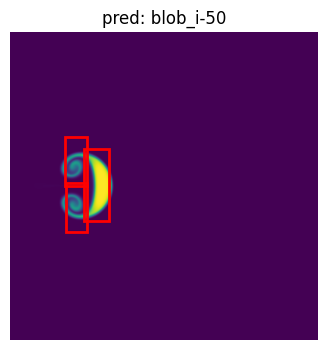

Top scores: [0.20405413 0.18352894 0.16673346]


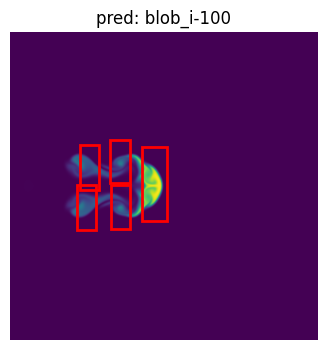

Top scores: [0.26693296 0.24300334 0.20711476 0.187919   0.16290808]


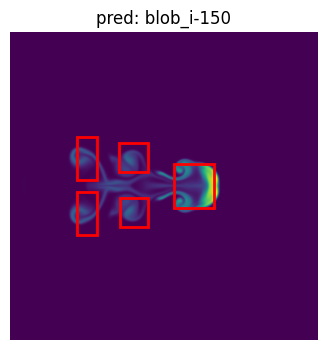

Top scores: [0.26887122 0.20446853 0.19749877 0.14872557 0.13662429]


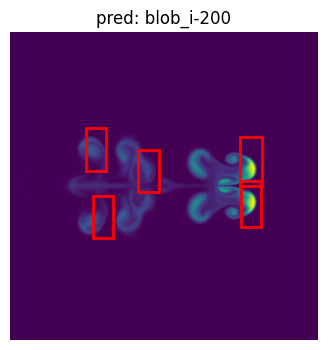

Top scores: [0.42574072 0.1664069  0.15944731 0.15936784 0.15676865]


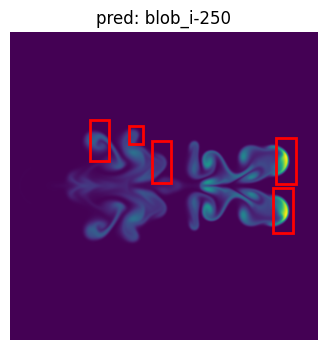

Top scores: [0.3652882  0.33513212 0.15674801 0.15473005 0.15164888]


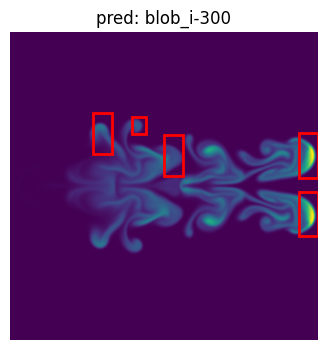

Top scores: [0.2882591  0.2800556  0.17699343 0.15481502 0.1437915 ]


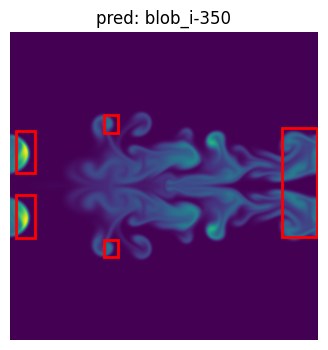

Top scores: [0.26252776 0.25732824 0.20136279 0.16411056 0.16119596]


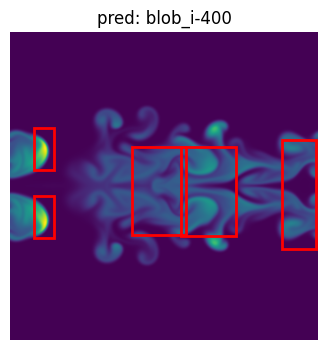

Top scores: [0.26176533 0.23216708 0.23183948 0.2277032  0.16062279]


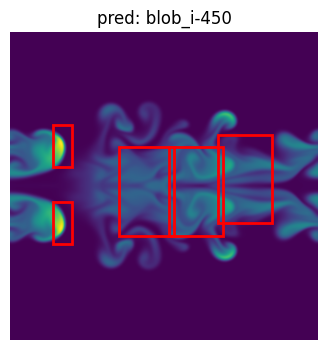

Top scores: [0.25945768 0.22796345 0.21036623 0.20814332 0.17533256]


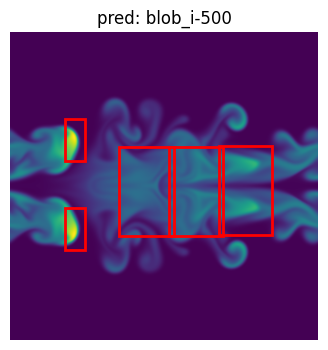

Top scores: [0.2517545  0.22847334 0.19503982 0.18973553 0.17699191]


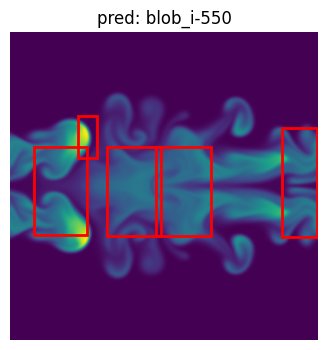

Top scores: [0.23445919 0.21353288 0.19214058 0.18885352 0.18638512]


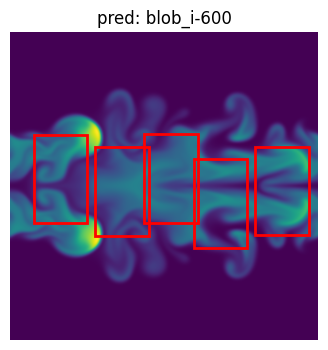

Top scores: [0.21444489 0.21009943 0.20491676 0.20008396 0.1822628 ]


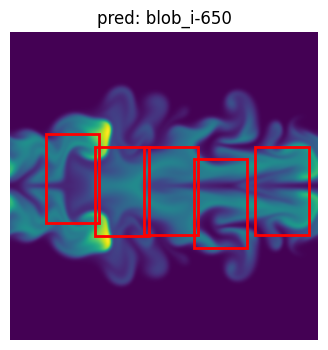

Top scores: [0.21005186 0.20658086 0.20505087 0.1944679  0.1809296 ]


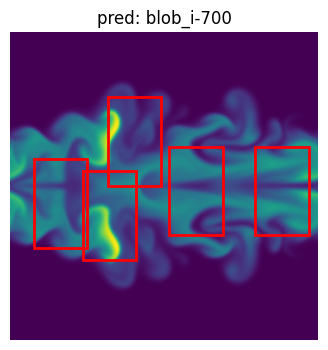

Top scores: [0.21016166 0.20805082 0.19619565 0.19243744 0.14348234]


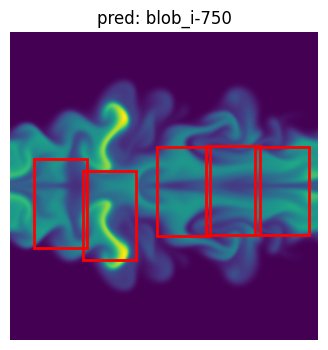

Top scores: [0.2065892  0.20514418 0.195253   0.19396384 0.18208392]


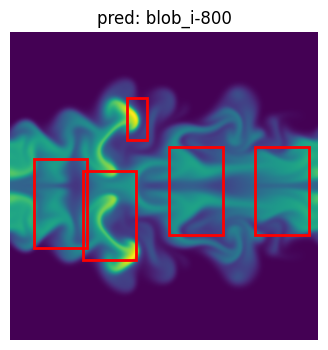

Top scores: [0.20279565 0.19881235 0.19518518 0.19139709 0.14358518]


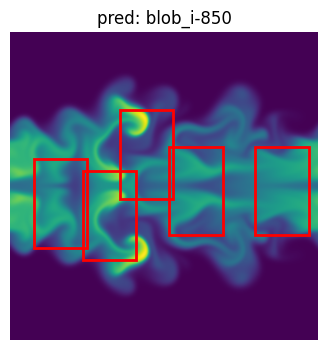

Top scores: [0.19760059 0.19624993 0.18982986 0.18957485 0.14720838]


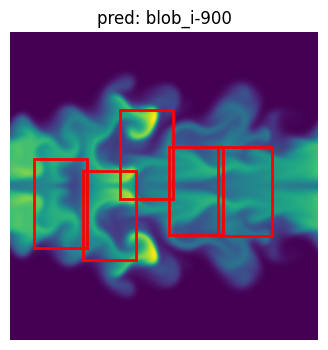

Top scores: [0.20042793 0.18843322 0.18810347 0.18746498 0.16076879]


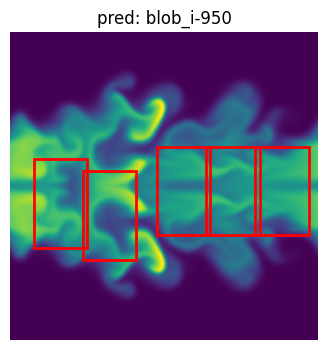

Top scores: [0.20281292 0.18760613 0.18168017 0.17946209 0.1720489 ]


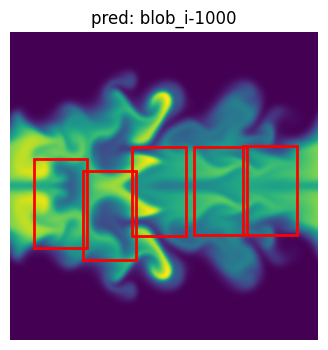

Top scores: [0.20440486 0.18676941 0.18593465 0.17014843 0.16720843]


In [7]:
# Visualize predictions on a few training frames
model.eval()
for i in range(20):
    image, target = train_dataset[i]
    with torch.no_grad():
        output = model([image])[0]
    boxes = output["boxes"].detach().cpu().numpy()
    scores = output["scores"].detach().cpu().numpy()

    # keep top few boxes for visualization
    keep = scores.argsort()[::-1][:5]
    show_frame_with_boxes(image, boxes[keep], title=f"pred: {target['frame_index']}")
    print("Top scores:", scores[keep])

No label files found
Loaded 4 frames.


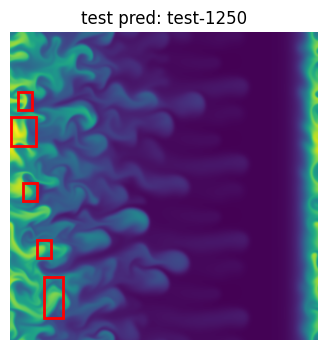

Top scores: [0.1988647  0.19557536 0.18672991 0.17458434 0.16671318]


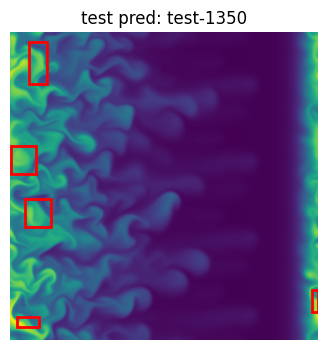

Top scores: [0.19581228 0.16549152 0.15583144 0.15253657 0.14279251]


In [8]:
# Visualize predictions on a few test frames",
# test_dir = repo_root / \"dev_phase\" / \"input_data\" / \"test\"",
test_dir = repo_root / "dev_phase" / "input_data" / "test"
test_dataset = TokamDataset(test_dir, include_unlabeled=True)
model.eval()
for i in range(2):
    image, target = test_dataset[i]
    with torch.no_grad():
        output = model([image])[0]
        boxes = output["boxes"].detach().cpu().numpy()
        scores = output["scores"].detach().cpu().numpy()
        keep = scores.argsort()[::-1][:5]
    show_frame_with_boxes(image, boxes[keep], title=f"test pred: {target['frame_index']}")
    print("Top scores:", scores[keep])

In [9]:
# Run ingestion locally to generate XML predictions
# from ingestion_program.ingestion import main as ingestion_main

# data_dir = repo_root / "dev_phase" / "input_data"
# output_dir = repo_root / "ingestion_res_local"

# ingestion_main(data_dir, output_dir)

# print("Generated:", list(output_dir.glob("*_predictions.xml")))
# print("Metadata:", output_dir / "metadata.json")

## Submission notes

- Only solution/submission.py is submitted.
- You cannot validate against the hidden test annotations locally.
- Use this notebook to iterate quickly, then submit your updated submission.py on the website.

https://chatgpt.com/share/6987cdec-2fa8-8009-bde1-33e519d0dd52